# Neural Networks From Scratch 

The aim of this notebook is to code from scratch a [2, 4, 1]-layer **neural network** using only NumPy, for a **binary classification problem** with the make_circles dataset. 

**Architecture**: Input(2) → Hidden(4, ReLU) → Output(1, Sigmoid)

**Dataset**: make_circles, non-linearly separable, 1000 samples

**Goal**: Show that a hidden layer learns non-linear boundaries that logistic regression cannot.

## 1. Imports

In [20]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from neural_network import NeuralNetwork, Layer

## 2. Generate a Synthetic Dataset

In [21]:
# Generate a synthetic dataset
n_samples = 1000
X, y = make_circles(n_samples=1000, random_state=42, factor=0.5, noise=0.1)
# y has shape (1000,) by default.
# We reshape it to (1, 1000) to stay consistent with the convention used
# throughout this notebook: every matrix has shape (features, samples).
y = y.reshape(1, -1) # Reshape y as (1, 1000) to be a row vector for easier matrix operations

In [22]:
print("X shape:", X.shape) # (1000, 2) with sklearn convention: (samples, features)
print("y shape:", y.shape) # (1, 1000) with our convention: (1, samples)

X shape: (1000, 2)
y shape: (1, 1000)


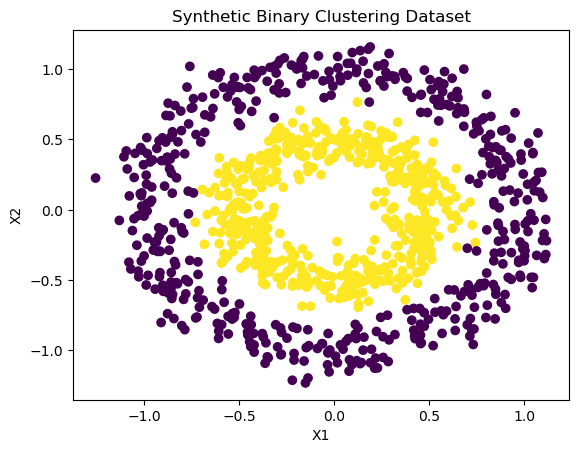

In [23]:
# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Synthetic Binary Clustering Dataset")
plt.show()

The two classes form concentric circles.

No straight line can separate them, so logistic regression will fail.

A neural network with a hidden layer will learn a circular boundary.

## 3. Initialize parameters

Network architecture: [2, 4, 1]

- Layer 1 (hidden) : 4 neurons, receives 2 inputs
- Layer 2 (output) : 1 neuron, receives 4 inputs

Weight matrix dimensions:
- W1 : (n_hidden, n_input)  = (4, 2)
- b1 : (n_hidden, 1)        = (4, 1)   ← broadcasts over m samples
- W2 : (n_output, n_hidden) = (1, 4)
- b2 : (n_output, 1)        = (1, 1)

Xavier / Glorot initialization:

W = np.random.randn(...) * sqrt(1 / n_prev)

This keeps the variance of activations stable as we go deeper.
- If weights are too large → activations saturate → gradients vanish.
- If weights are too small → signal too weak to propagate.

Why NOT initialize to zero?
- Every neuron in a layer would compute the same output and receive the same gradient → they never differentiate (symmetry problem).
- Random init breaks symmetry: each neuron learns a different feature.

Biases are safe to initialize to zero (symmetry is broken by W).

In [24]:
# Initialize parameters for a [2, 4, 1] neural network
np.random.seed(42)  # for reproducibility
W1 = np.random.randn(4, 2) * np.sqrt(1/2) # (4, 2)
b1 = np.zeros((4, 1)) # (4, 1)

W2 = np.random.randn(1, 4) * np.sqrt(1/4) # (1, 4)
b2 = np.zeros((1, 1)) # (1, 1)

In [25]:
print("W1 shape:", W1.shape)
print("b1 shape:", b1.shape)
print("W2 shape:", W2.shape)
print("b2 shape:", b2.shape)

W1 shape: (4, 2)
b1 shape: (4, 1)
W2 shape: (1, 4)
b2 shape: (1, 1)


In [26]:
print("W2:", W2)
print("b2:", b2)
print("W1:", W1)
print("b1:", b1)

W2: [[-0.23473719  0.27128002 -0.23170885 -0.23286488]]
b2: [[0.]]
W1: [[ 0.35122995 -0.09776762]
 [ 0.45798496  1.07694474]
 [-0.16557144 -0.16555983]
 [ 1.11667209  0.5426583 ]]
b1: [[0.]
 [0.]
 [0.]
 [0.]]


## 4. Activation functions

**SIGMOID**:  σ(z) = 1 / (1 + e^{-z})
 
- Output range: (0, 1) → used for the output layer (binary probability)
- Derivative: σ'(z) = σ(z) * (1 − σ(z)) = A * (1 − A)

Note: if A = σ(Z) is already computed, we use A*(1-A) directly, no need to recompute from Z.

In [27]:
# Sigmoid activation function
def sigmoid(z):
    # Sigmoid(z) = 1 / (1 + exp(-z))
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    # Sigmoid'(z) = sigmoid(z) * (1 - sigmoid(z))
    s = sigmoid(z)
    return s * (1 - s)

**RELU**: f(z) = max(0, z)

- Output range : [0, +∞)  → used for the hidden layer
- Derivative   : 1 if z > 0, else 0

Why prefer ReLU in hidden layers over sigmoid?
- Sigmoid derivative A*(1-A) ≤ 0.25 always.
- In backprop, each hidden layer multiplies the gradient by this factor.
- With 2+ layers, the gradient shrinks exponentially → vanishing gradient problem.
- ReLU derivative = 1 for z > 0, so the gradient passes through unchanged.

In [28]:
# ReLU activation function
def relu(z):
    # ReLU(z) = max(0, z)
    return np.maximum(0, z)

def relu_derivative(z):
    # ReLU'(z) = 1 if z > 0, else 0
    # Applied element-wise on Z (not A), this is why we store Z during forward
    return (z > 0).astype(float)

## 5. Forward pass (one pass, before training)

**Convention**: X is stored as (samples, features) by sklearn.

We transpose it once to (features, samples) = (2, 1000) so that all matrix operations follow the convention (n, m) throughout.

**Layer 1**:
- Z¹ = W¹ · X^T + b¹
- (4,2) x (2,1000) + (4,1) → shape (4, 1000)
- A¹ = ReLU(Z¹) → shape (4, 1000)

**Layer 2**:
- Z² = W² · A¹ + b²
- (1,4) x (4,1000) + (1,1) → shape (1, 1000)
- A² = σ(Z²) →  shape (1, 1000)  ← final prediction ŷ

In [29]:
# Forward pass
# Layer 1
Z1 = W1 @ X.T + b1 # Linear transformation for layer 1 (4, 1000)
A1 = sigmoid(Z1) # Activation for layer 1 (4, 1000): hidden layer output

# Layer 2
Z2 = W2 @ A1 + b2 # Linear transformation for layer 2 (1, 1000)
A2 = sigmoid(Z2) # Activation for layer 2 (1, 1000): output layer output, predicted probabilities ŷ ∈ (0, 1)

In [30]:
print("Z1 shape:", Z1.shape)
print("A1 shape:", A1.shape)
print("Z2 shape:", Z2.shape)
print("A2 shape:", A2.shape)

Z1 shape: (4, 1000)
A1 shape: (4, 1000)
Z2 shape: (1, 1000)
A2 shape: (1, 1000)


## 6. Loss function

**Binary Cross-Entropy (BCE)**: L = − (1/m) · Σ [ y·log(ŷ) + (1−y)·log(1−ŷ) ]

Intuition:
- If y=1 and ŷ≈1 → log(ŷ) ≈ 0 → low loss (correct prediction)
- If y=1 and ŷ≈0 → log(ŷ) → -∞ → high loss (wrong prediction)
Same logic applies symmetrically for y=0.

Expected initial value on a balanced dataset with random weights:
- All predictions ≈ 0.5 → BCE = log(2) ≈ 0.693
- This is our sanity check: if the initial loss is far from 0.693, something is wrong with the initialization or forward pass.

Note on y.size vs y.shape[0]:
- y has shape (1, 1000), so y.shape[0] = 1 (wrong m).
- y.size = 1000 (correct m), regardless of shape convention.

In [31]:
# Define the Binary Cross-Entropy Loss function
def compute_loss(y, y_hat):
    m = y.size # total number of elements, safe regardless of shape
    loss = -(1 / m) * np.sum(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return loss

In [32]:
# Compute the Binary Cross-Entropy Loss
loss = compute_loss(y, A2)
print("Binary Cross Entropy Loss:", loss) # should be ≈ 0.693

Binary Cross Entropy Loss: 0.6990075427918853


In [33]:
print("y shape:", y.shape)
print("A2 shape:", A2.shape)

y shape: (1, 1000)
A2 shape: (1, 1000)


## 7. Backpropagation (one step)

**Goal**: verify that one gradient descent step decreases the loss.

**LAYER 2 - output layer**:

δ² = dL/dZ²
   = dL/dA² * dA²/dZ²
   = [−(1/m)(y/A² − (1−y)/(1−A²))] * [A²(1−A²)]
   = (1/m)(A² − y) ← simplification of BCE * sigmoid derivative

Shape: (1, 1000)

dW² = dL/dW² = δ² * (A¹)ᵀ

Shape: (1, 1000) * (1000, 4) = (1, 4), same as W²

db² = mean(δ², axis=1, keepdims=True)

Shape: (1, 1), same as b²

dA¹ = (W²)ᵀ * δ² ← gradient passed to layer 1

Shape: (4, 1) * (1, 1000) = (4, 1000), same as A¹

**LAYER 1 - hidden layer**:
#
δ¹ = dL/dZ¹
   = dA¹ * ReLU'(Z¹) ← element-wise (*)

Shape: (4, 1000)

Note: we use ReLU'(Z¹), not A¹* (1−A¹), because layer 1 uses ReLU.

We apply the derivative on Z¹ (stored during forward pass), not on A¹.

dW¹ = δ¹ * X

Shape: (4, 1000) * (1000, 2) = (4, 2)  ✓ same as W¹

(Here X is used as (A⁰)ᵀ because A⁰ = X.T, so (A⁰)ᵀ = (X.T)ᵀ = X.)

db¹ = mean(δ¹, axis=1, keepdims=True)

Shape: (4, 1), same as b¹

In [34]:
# Backpropagation with sigmoid activation in both layers
# Layer 2 
delta2 = (1/n_samples) * (A2 - y) # Derivative of loss w.r.t Z2 (dL/dZ2)
dW2 = delta2 @ A1.T # Derivative of loss w.r.t W (dL/dW2)
db2 = np.mean(delta2, axis=1, keepdims=True) # Derivative of loss w.r.t b (dL/db2)
dA1 = W2.T @ delta2 # Derivative of loss w.r.t A1 (dL/dA1)

# Layer 1
delta1 = dA1 * A1 * (1 - A1) # Derivative of loss w.r.t Z1 (dL/dZ1)
dW1 = delta1 @ X # Derivative of loss w.r.t W (dL/dW1), with X as (X.T).T = A[0].T
db1 = np.mean(delta1, axis=1, keepdims=True) # Derivative of loss w.r.t b (dL/db1)

In [35]:
print("delta2 shape:", delta2.shape)
print("dW2 shape:", dW2.shape)
print("db2 shape:", db2.shape)
print("dA1 shape:", dA1.shape)
print("delta1 shape:", delta1.shape)
print("dW1 shape:", dW1.shape)
print("db1 shape:", db1.shape)

delta2 shape: (1, 1000)
dW2 shape: (1, 4)
db2 shape: (1, 1)
dA1 shape: (4, 1000)
delta1 shape: (4, 1000)
dW1 shape: (4, 2)
db1 shape: (4, 1)


## 8. One update step

Gradient descent update rule (same for all algorithms):

W ← W − α * dW

b ← b − α * db

α (learning_rate) controls the step size.
- Too large → overshoots the minimum, loss diverges.
- Too small → very slow convergence.

In [36]:
# Update parameters
learning_rate = 0.01

W2 -= learning_rate * dW2
b2 -= learning_rate * db2
W1 -= learning_rate * dW1
b1 -= learning_rate * db1

In [37]:
print("W2:", W2)
print("b2:", b2)
print("W1:", W1)
print("b1:", b1)

W2: [[-0.23446755  0.27153822 -0.23144157 -0.2325977 ]]
b2: [[5.33028009e-07]]
W1: [[ 0.35122857 -0.09776516]
 [ 0.45798637  1.07694224]
 [-0.16557283 -0.16555737]
 [ 1.11667084  0.54266077]]
b1: [[-3.26654222e-08]
 [ 5.02684913e-08]
 [-3.14640981e-08]
 [-4.38257447e-08]]


In [38]:
# Forward pass after update
# Layer 1
Z1_new = W1 @ X.T + b1 # Linear transformation for layer 1
A1_new = relu(Z1_new) # Activation for layer 1

# Layer 2
Z2_new = W2 @ A1_new + b2 # Linear transformation for layer 2
A2_new = sigmoid(Z2_new) # Activation for layer 2

In [39]:
# Compute the BCE Loss after one update
loss_after_update = compute_loss(y, A2_new)
print("Binary Cross Entropy Loss After Update:", loss_after_update)

Binary Cross Entropy Loss After Update: 0.6903998585632339


Loss after update < loss before update, so gradient and update are correct.

## 9. Full training loop

One training iteration = forward pass + loss + backward pass + update.

We repeat this n_iterations times (= one epoch over the full dataset, since we use batch gradient descent, all samples at once).

At each iteration we store the loss to plot the learning curve.

In [40]:
# Backpropagation loop 
np.random.seed(42)   # re-initialize for a clean run
W1 = np.random.randn(4, 2) * np.sqrt(1 / 2)
b1 = np.zeros((4, 1))
W2 = np.random.randn(1, 4) * np.sqrt(1 / 4)
b2 = np.zeros((1, 1))

learning_rate = 1
n_iterations = 10000
loss_iterations = []
for i in range(n_iterations):
    # Forward pass
    Z1 = W1 @ X.T + b1 # pre-activation layer 1
    A1 = relu(Z1) # post-activation layer 1  (stored for backward)
    Z2 = W2 @ A1 + b2 # pre-activation layer 2
    A2 = sigmoid(Z2) # post-activation layer 2 = predictions ŷ

    # Compute loss
    loss = compute_loss(y, A2)
    loss_iterations.append(loss)

    # Backpropagation
    delta2 = (1/n_samples) * (A2 - y) # dL/dW2 = delta2 * dZ2/dW2 = delta2 * A1
    dW2 = delta2 @ A1.T # dL/dW2 = delta2 * dZ2/dW2 = delta2 * A1
    db2 = np.mean(delta2, axis=1, keepdims=True) # dL/db2 = delta2 * dZ2/db2 = delta2 * 1
    dA1 = W2.T @ delta2 # dL/dA1 = dL/dZ2 * dZ2/dA1 = delta2 * W2

    # To prevent vanishing gradients, we use the derivative of ReLU for layer 1
    delta1 = dA1 * relu_derivative(Z1) # delta1 = dL/dZ1 = dL/dA1 * dA1/dZ1
    dW1 = delta1 @ X # dL/dW1 = delta1 * dZ1/dW1 = delta1 * A0, A0 = X.T, donc (A0).T = X
    db1 = np.mean(delta1, axis=1, keepdims=True)

    # Update parameters
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    # Print loss every 1000 iterations
    if (i + 1) % 1000 == 0:
        print(f"Iteration {i+1:5d} - Loss: {loss:.4f}")

Iteration  1000 - Loss: 0.5978
Iteration  2000 - Loss: 0.4784
Iteration  3000 - Loss: 0.3897
Iteration  4000 - Loss: 0.3341
Iteration  5000 - Loss: 0.2852
Iteration  6000 - Loss: 0.2461
Iteration  7000 - Loss: 0.2227
Iteration  8000 - Loss: 0.2042
Iteration  9000 - Loss: 0.1882
Iteration 10000 - Loss: 0.1730


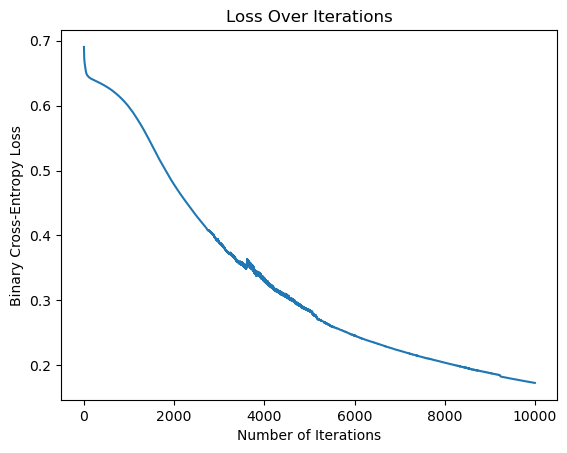

In [41]:
# Visualize loss over iterations (learning curve)
plt.plot(loss_iterations)
plt.xlabel("Number of Iterations")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Loss Over Iterations")
plt.show()

## 10. Predict and evaluate

Prediction = forward pass → threshold at 0.5
- ŷ > 0.5 → predicted class 1
- ŷ ≤ 0.5 → predicted class 0

In [42]:
# Predict function for the trained model
def predict(X):
    Z1 = W1 @ X.T + b1
    A1 = relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)
    return (A2 > 0.5).astype(int)

In [43]:
# Final predictions
predictions = predict(X)
accuracy = np.mean(predictions == y)
print("Final Accuracy:", accuracy)

Final Accuracy: 0.976


## 11. Decision boundary 

We create a dense grid of points covering the feature space, predict the class for each point, and colour the background accordingly.

This reveals the shape of the decision boundary learned by the network.

Unlike logistic regression (straight line), ours is curved/circular.

In [44]:
# Visualization of decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = predict(grid_points)
Z = Z.reshape(xx.shape)

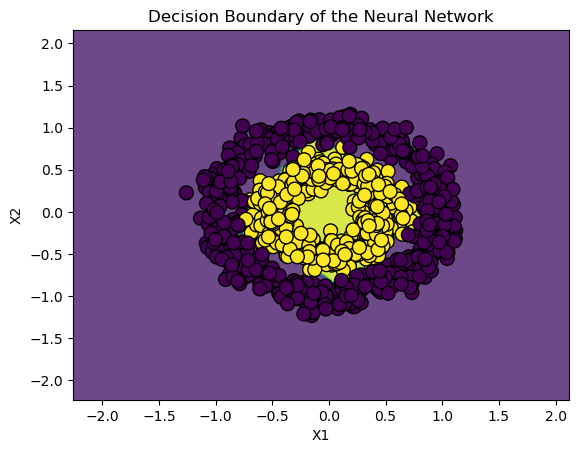

In [45]:
plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), edgecolors='k', marker='o', s=100, cmap='viridis')
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Decision Boundary of the Neural Network")
plt.show()

The boundary is non-linear (roughly circular), proof that the hidden layer learned a non-linear transformation of the input space.

## 11. Test the Neural Network from scratch model

In [46]:
# Initialize the neural nerwork
np.random.seed(42)
nn = NeuralNetwork()
nn.add(Layer(4, 'relu'))
nn.add(Layer(1, 'sigmoid'))

In [47]:
# Fit and train the model
nn.fit(X, y, learning_rate=0.001, n_iterations=10000)

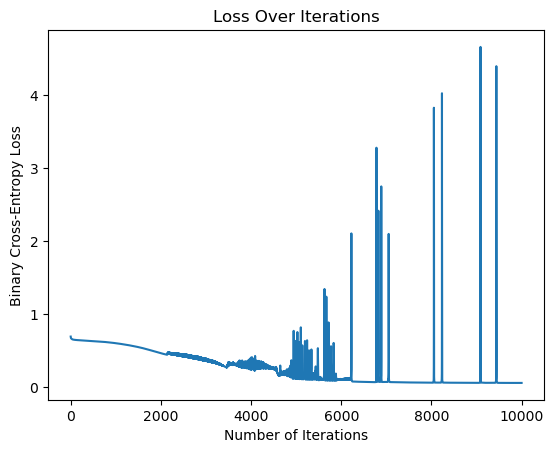

In [48]:
# Visualize loss over iterations (learning curve)
plt.plot(nn.loss_history)
plt.xlabel("Number of Iterations")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Loss Over Iterations")
plt.show()

In [49]:
# Final predictions
predictions = nn.predict(X)
accuracy = np.mean(predictions == y)
print(f"Accuracy: {accuracy * 100:.1f}%")

Accuracy: 98.3%


With a learning_rate=0.001, we have an excellent **accurary of 98.3%**. 

The curve is noisy but does indeed drop down to ~0.

The spike around iteration 3000 is a sign that the learning rate is still a bit high at times, mearning the network is navigating a difficult part of the learning landscape. This is normal.

First descent (0–5000): the network is learning normally, with the usual spike around 2500 that we’ve seen before.

Flat plateau around 10,000: the loss is nearly zero—the network has found a very good solution. The weights are in a flat region of the learning landscape.

Second spike around 12,000–13,000: this is catastrophic overshooting. Even with lr=0.001, the network enters a very flat region where gradients become tiny, then suddenly traverses a region with steep curvature and the weights temporarily spike.

Final recovery: the **network stabilizes again and converges to ~0**.

This is a known behavior with classical gradient descent. It’s exactly why optimizers like Adam exist. Adam adapts the learning rate per parameter and avoids these explosions.

In [50]:
print("y_hat sample:", nn.forward(X)[:, :5])
print("predictions sample:", nn.predict(X)[:, :5])

y_hat sample: [[0.99991939 0.99993531 0.99713969 0.99952856 0.00100358]]
predictions sample: [[1 1 1 1 0]]
